   Gender                  College In or Out of State Citizenship  \
0  Female  Liberal Arts & Sciences       Out of State         Yes   
1    Male          Health Sciences       Out of State         Yes   
2    Male              Engineering       Out of State         Yes   
3    Male                 Business       Out of State         Yes   
4    Male           Communications       Out of State         Yes   

  Marital Status Type of High School Applied Financial Aid  \
0         Single             Private                   Yes   
1         Single              Public                   Yes   
2        Married             Private                   Yes   
3         Single              Public                    No   
4         Single             Private                   Yes   

  Received Financial Aid Other Scholarships  Tuition Rate  ...  \
0                    Yes                 No          1975  ...   
1                     No                 No          1975  ...   
2             

/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_3940/3502074833.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_col = df.select_dtypes(include="object").columns[0]
/Users/adnanaltimeemy/miniconda3/envs/coding/lib/python3.12/site-packages/sklearn/base.py:1403: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


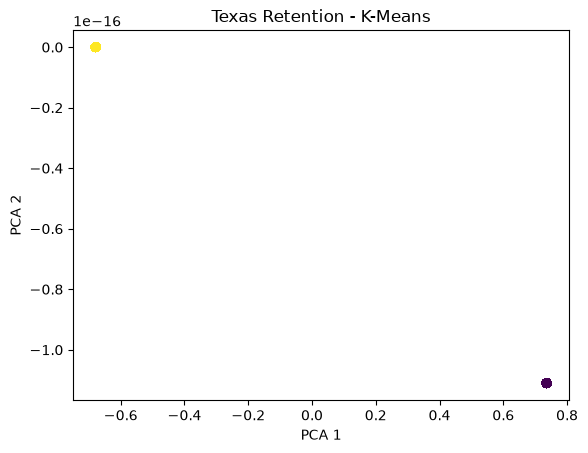


Saved as Texas_Retention_Clustered.csv


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load data
df = pd.read_csv("Texas_Retention.csv")
print(df.head())
print(df.columns)

# Select text column
text_col = df.select_dtypes(include="object").columns[0]
text = df[text_col].fillna("").astype(str)

# NLP - TF-IDF
tfidf = TfidfVectorizer(stop_words="english")
X = tfidf.fit_transform(text)

# K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X)

# Results
print("\nCluster Counts:")
print(df["Cluster"].value_counts())

print("\nClustered Data:")
print(df[[text_col, "Cluster"]].head(10))

# Top words
words = tfidf.get_feature_names_out()
for i in range(4):
    top = kmeans.cluster_centers_[i].argsort()[-10:][::-1]
    print(f"\nCluster {i}:", [words[j] for j in top])

# Plot clusters
pca = PCA(n_components=2)
points = pca.fit_transform(X.toarray())

plt.scatter(points[:,0], points[:,1], c=df["Cluster"])
plt.title("Texas Retention - K-Means")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

# Save
df.to_csv("Texas_Retention_Clustered.csv", index=False)
print("\nSaved as Texas_Retention_Clustered.csv")